In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import models, layers


In [81]:
# Load data
df = pd.read_csv("../data/prostate_cancer_prediction.csv")
# df1 = pd.read_excel("../data/prostate_data2.xlsx", header=1)

In [82]:
df.head()

,Patient_ID,Age,Family_History,Race_African_Ancestry,PSA_Level,DRE_Result,Biopsy_Result,Difficulty_Urinating,Weak_Urine_Flow,Blood_in_Urine,...,Alcohol_Consumption,Hypertension,Diabetes,Cholesterol_Level,Screening_Age,Follow_Up_Required,Prostate_Volume,Genetic_Risk_Factors,Previous_Cancer_History,Early_Detection
0,1,78,No,Yes,5.07,Normal,Benign,No,No,No,...,Moderate,No,No,Normal,45,No,46.0,No,No,Yes
1,2,68,No,Yes,10.24,Normal,Benign,Yes,No,No,...,Low,No,No,High,65,No,78.2,No,No,Yes
2,3,54,No,No,13.79,Normal,Benign,No,No,No,...,Low,No,No,Normal,61,No,21.1,No,No,Yes
3,4,82,No,No,8.03,Abnormal,Benign,No,No,No,...,Low,No,No,Normal,47,Yes,79.9,No,Yes,Yes
4,5,47,Yes,No,1.89,Normal,Malignant,Yes,Yes,No,...,Moderate,Yes,No,Normal,72,No,32.0,No,No,Yes


In [83]:
df.columns

Index(['Patient_ID', 'Age', 'Family_History', 'Race_African_Ancestry',
       'PSA_Level', 'DRE_Result', 'Biopsy_Result', 'Difficulty_Urinating',
       'Weak_Urine_Flow', 'Blood_in_Urine', 'Pelvic_Pain', 'Back_Pain',
       'Erectile_Dysfunction', 'Cancer_Stage', 'Treatment_Recommended',
       'Survival_5_Years', 'Exercise_Regularly', 'Healthy_Diet', 'BMI',
       'Smoking_History', 'Alcohol_Consumption', 'Hypertension', 'Diabetes',
       'Cholesterol_Level', 'Screening_Age', 'Follow_Up_Required',
       'Prostate_Volume', 'Genetic_Risk_Factors', 'Previous_Cancer_History',
       'Early_Detection'],
      dtype='object')

In [84]:
df["Early_Detection"].value_counts()

Early_Detection
Yes    23747
No      4198
Name: count, dtype: int64

In [85]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   No.              300 non-null    int64  
 1   Age              300 non-null    int64  
 2   BMI              300 non-null    float64
 3   RBC              300 non-null    float64
 4   HGB              300 non-null    int64  
 5   WBC              300 non-null    float64
 6   PLT              300 non-null    float64
 7   PMN              300 non-null    float64
 8   LYMPH            300 non-null    float64
 9   MONOC            300 non-null    float64
 10  tPSA             300 non-null    float64
 11  fPSA             300 non-null    float64
 12  PV               300 non-null    float64
 13  PSAD             300 non-null    float64
 14  GLU              300 non-null    float64
 15  CRE              300 non-null    int64  
 16  ALT              300 non-null    int64  
 17  AST             

In [86]:
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df[df['Early_Detection'] == 'Yes']
df_minority = df[df['Early_Detection'] == 'No']

# Undersample majority class (reduce to ~11,800)
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=11800,
    random_state=42
)


In [87]:
from sklearn.preprocessing import LabelEncoder

df_combined = pd.concat([df_majority_downsampled, df_minority])
categorical_cols = df_combined.select_dtypes(include='object').columns.drop(['Early_Detection'])

# Encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    df_combined[col] = le.fit_transform(df_combined[col])

# Separate features and target
X = df_combined.drop(['Patient_ID', 'Early_Detection'], axis=1)
y = df_combined['Early_Detection']


In [88]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=0.4, random_state=42)
X_res, y_res = sm.fit_resample(X, y)


In [89]:
# Recombine X and y
df_resampled = X_res.copy()
df_resampled['Early_Detection'] = y_res

# Shuffle
df_resampled = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)


In [90]:
print(df_resampled['Early_Detection'].value_counts())


Early_Detection
Yes    11800
No      4720
Name: count, dtype: int64


In [ ]:
from sdv.tabular import CTGAN
import pandas as pd

# Focus only on the minority class ("No")
minority_df = df[df['Early_Detection'] == 'No'].copy()

# Drop identifier
minority_df = minority_df.drop(columns=['Patient_ID'])

# Optional: convert target column to a string if needed (CTGAN handles categorical better this way)
minority_df['Early_Detection'] = minority_df['Early_Detection'].astype(str)


In [ ]:
ctgan = CTGAN(epochs=300)  # You can tweak the number of training epochs
ctgan.fit(minority_df)

In [ ]:
synthetic_minority = ctgan.sample(4000)

# Confirm all generated samples have minority label
assert synthetic_minority['Early_Detection'].nunique() == 1


In [ ]:
from sklearn.utils import resample

# Reduce majority class
majority_df = df[df['Early_Detection'] == 'Yes']
majority_downsampled = resample(majority_df, n_samples=11000, random_state=42)

# Combine all
final_df = pd.concat([majority_downsampled, minority_df, synthetic_minority], ignore_index=True)

# Shuffle
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
print(final_df['Early_Detection'].value_counts())


In [4]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Convert target to binary
df_encoded["Early_Detection"] = df_encoded["Early_Detection"].map({"Yes": 1, "No": 0})

# Label encode categorical features
categorical_cols = [
    "Family_History", "DRE_Result", "Biopsy_Result", "Difficulty_Urinating",
    "Weak_Urine_Flow", "Blood_in_Urine", "Erectile_Dysfunction",
    "Cancer_Stage", "Genetic_Risk_Factors", "Diabetes"
]

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [5]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(["Patient_ID", "Early_Detection"], axis=1)
y = df_encoded["Early_Detection"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.644
              precision    recall  f1-score   support

           0       0.55      0.02      0.03       714
           1       0.64      0.99      0.78      1286

    accuracy                           0.64      2000
   macro avg       0.60      0.50      0.41      2000
weighted avg       0.61      0.64      0.51      2000



In [7]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

mlp.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, class_weight=class_weight_dict)


TypeError: BaseMultilayerPerceptron.fit() got an unexpected keyword argument 'epochs'

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
df["Early_Detection"].value_counts()


Early_Detection
Yes    6290
No     3710
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [11]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.neural_network import MLPClassifier

# Compute sample weights manually
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Initialize and train the model
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)


NameError: name 'X_train_scaled' is not defined

In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Train/test split on the resampled data
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Train MLP
MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',      # try 'tanh' or 'logistic'
    solver='adam',          # try 'sgd'
    alpha=1e-4,             # L2 penalty (try 1e-3 to 1e-6)
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_res, y_train_res)


MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

Accuracy: 0.649

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      1243
           1       0.65      0.67      0.66      1273

    accuracy                           0.65      2516
   macro avg       0.65      0.65      0.65      2516
weighted avg       0.65      0.65      0.65      2516



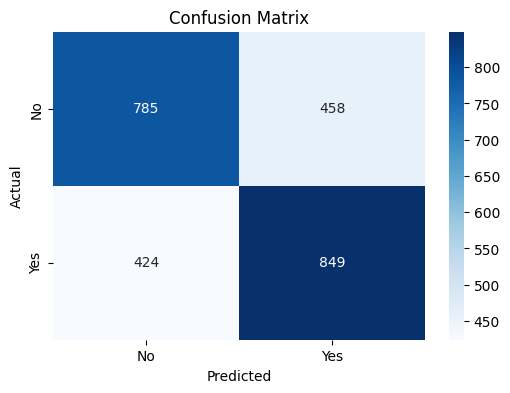

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = mlp.predict(X_test_res)

# Accuracy
accuracy = accuracy_score(y_test_res, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_res, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_res, y_pred)

# Confusion Matrix Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [19]:
result = permutation_importance(
    rf, X_train_res, y_train_res, n_repeats=10, random_state=42, n_jobs=-1
)


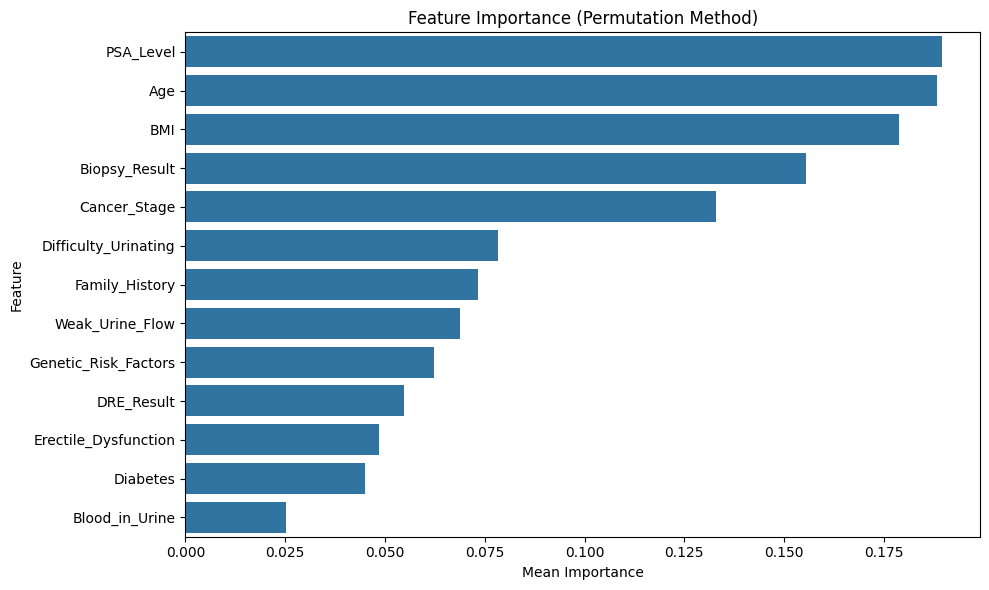

In [20]:
# Create DataFrame
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
})

# Sort by importance
importance_df = importance_df.sort_values(by='importance_mean', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=importance_df)
plt.title('Feature Importance (Permutation Method)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [21]:
# Sort feature names by importance
sorted_features = importance_df.sort_values(by='importance_mean', ascending=False)['feature'].tolist()

# Print as a Python list
print(sorted_features)


['PSA_Level', 'Age', 'BMI', 'Biopsy_Result', 'Cancer_Stage', 'Difficulty_Urinating', 'Family_History', 'Weak_Urine_Flow', 'Genetic_Risk_Factors', 'DRE_Result', 'Erectile_Dysfunction', 'Diabetes', 'Blood_in_Urine']


Accuracy: 0.641

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.00      0.01       714
           1       0.64      0.99      0.78      1286

    accuracy                           0.64      2000
   macro avg       0.47      0.50      0.39      2000
weighted avg       0.52      0.64      0.51      2000



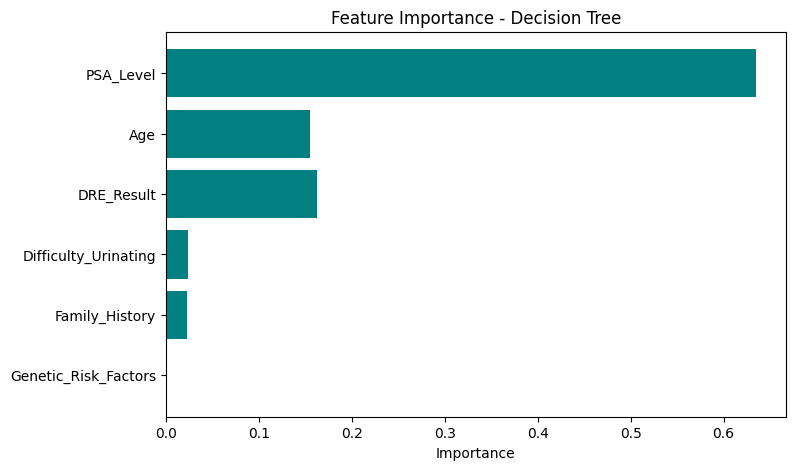

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

top_features = [
    'PSA_Level', 'Age', 'DRE_Result', 'Difficulty_Urinating',
    'Family_History', 'Genetic_Risk_Factors'
]

# 1. Filter dataset
X_selected = X[top_features]

# 2. Train-test split (if not already done)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# 3. Train decision tree model
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# 4. Evaluate
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Feature Importance
import matplotlib.pyplot as plt

importances = dt.feature_importances_
feature_names = X_selected.columns

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color='teal')
plt.xlabel("Importance")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()


In [3]:
# Original counts
original_counts = df['Early_Detection'].value_counts()
print("Original Distribution:")
print(original_counts)
print("\nOriginal Percentages:")
print(original_counts / len(df))

# Calculate target counts for 70:30 ratio
minority_count = original_counts['No']
majority_target = int(minority_count * (0.7/0.3)) 

Original Distribution:
Early_Detection
Yes    23747
No      4198
Name: count, dtype: int64

Original Percentages:
Early_Detection
Yes    0.849776
No     0.150224
Name: count, dtype: float64


In [4]:
df.columns

Index(['Patient_ID', 'Age', 'Family_History', 'Race_African_Ancestry',
       'PSA_Level', 'DRE_Result', 'Biopsy_Result', 'Difficulty_Urinating',
       'Weak_Urine_Flow', 'Blood_in_Urine', 'Pelvic_Pain', 'Back_Pain',
       'Erectile_Dysfunction', 'Cancer_Stage', 'Treatment_Recommended',
       'Survival_5_Years', 'Exercise_Regularly', 'Healthy_Diet', 'BMI',
       'Smoking_History', 'Alcohol_Consumption', 'Hypertension', 'Diabetes',
       'Cholesterol_Level', 'Screening_Age', 'Follow_Up_Required',
       'Prostate_Volume', 'Genetic_Risk_Factors', 'Previous_Cancer_History',
       'Early_Detection'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27945 entries, 0 to 27944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               27945 non-null  int64  
 1   Age                      27945 non-null  int64  
 2   Family_History           27945 non-null  object 
 3   Race_African_Ancestry    27945 non-null  object 
 4   PSA_Level                27945 non-null  float64
 5   DRE_Result               27945 non-null  object 
 6   Biopsy_Result            27945 non-null  object 
 7   Difficulty_Urinating     27945 non-null  object 
 8   Weak_Urine_Flow          27945 non-null  object 
 9   Blood_in_Urine           27945 non-null  object 
 10  Pelvic_Pain              27945 non-null  object 
 11  Back_Pain                27945 non-null  object 
 12  Erectile_Dysfunction     27945 non-null  object 
 13  Cancer_Stage             27945 non-null  object 
 14  Treatment_Recommended 

In [7]:
df.describe()

,Patient_ID,Age,PSA_Level,BMI,Screening_Age,Prostate_Volume
count,27945.000000,27945.000000,27945.000000,27945.000000,27945.000000,27945.000000
mean,13973.000000,64.459939,7.751599,26.511605,56.902308,47.755770
std,8067.170973,14.404755,4.175012,4.888293,10.118064,18.704286
min,1.000000,40.000000,0.500000,18.000000,40.000000,15.000000
25%,6987.000000,52.000000,4.130000,22.300000,48.000000,31.700000
50%,13973.000000,64.000000,7.750000,26.500000,57.000000,47.700000
75%,20959.000000,77.000000,11.320000,30.700000,66.000000,63.900000
max,27945.000000,89.000000,15.000000,35.000000,74.000000,80.000000


In [8]:
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df[df['Early_Detection'] == 'Yes']
df_minority = df[df['Early_Detection'] == 'No']

# Undersample majority class (reduce to ~11,800)
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=11800,
    random_state=42
)


In [9]:
from sklearn.preprocessing import LabelEncoder

df_combined = pd.concat([df_majority_downsampled, df_minority])
categorical_cols = df_combined.select_dtypes(include='object').columns.drop(['Early_Detection'])

# Encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    df_combined[col] = le.fit_transform(df_combined[col])

# Separate features and target
X = df_combined.drop(['Patient_ID', 'Early_Detection'], axis=1)
y = df_combined['Early_Detection']


In [10]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(sampling_strategy=0.4, random_state=42)
X_res, y_res = sm.fit_resample(X, y)


In [11]:
# Recombine X and y
df_resampled = X_res.copy()
df_resampled['Early_Detection'] = y_res

# Shuffle
df_resampled = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)


In [12]:
print(df_resampled['Early_Detection'].value_counts())


Early_Detection
Yes    11800
No      4720
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import LabelEncoder

df_balancing = pd.concat([df_majority_downsampled, df_minority], axis=0)

categorical_cols = df_balancing.select_dtypes(include='object').columns.drop('Early_Detection')
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_balancing[col] = le.fit_transform(df_balancing[col])
    le_dict[col] = le  # Store for inverse transform if needed


In [14]:
from imblearn.over_sampling import SMOTE

X = df_balancing.drop(['Patient_ID', 'Early_Detection'], axis=1)
y = df_balancing['Early_Detection']

# Define the desired count manually
smote = SMOTE(sampling_strategy={'No': 7867}, random_state=42)
X_res, y_res = smote.fit_resample(X, y)


In [15]:
import pandas as pd

# Recombine
df_resampled = X_res.copy()
df_resampled['Early_Detection'] = y_res

# Shuffle
df_resampled = df_resampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
print(df_resampled['Early_Detection'].value_counts())


Early_Detection
Yes    11800
No      7867
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df_resampled.drop(['Early_Detection'], axis=1)
y = df_resampled['Early_Detection']

# Train-test split (80-20), stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
   class_weight={'No': 2, 'Yes': 1}
)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight={'No': 2, 'Yes': 1}, random_state=42)

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # for AUC

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# AUC Score
auc = roc_auc_score((y_test == 'Yes').astype(int), y_prob)
print(f"\nROC AUC Score: {auc:.4f}")


Confusion Matrix:
[[ 706  868]
 [ 162 2198]]

Classification Report:
              precision    recall  f1-score   support

          No     0.8134    0.4485    0.5782      1574
         Yes     0.7169    0.9314    0.8102      2360

    accuracy                         0.7382      3934
   macro avg     0.7651    0.6899    0.6942      3934
weighted avg     0.7555    0.7382    0.7174      3934


ROC AUC Score: 0.7444


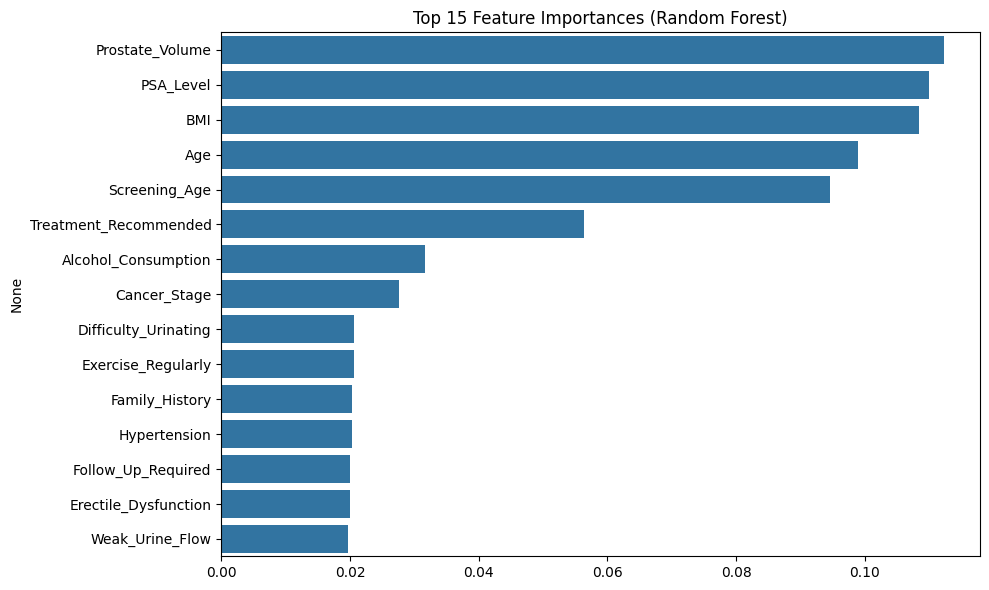

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
feat_names = X.columns

# Plot top 15
indices = importances.argsort()[::-1][:15]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feat_names[indices])
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


In [20]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42
)
brf.fit(X_train, y_train)


BalancedRandomForestClassifier(random_state=42)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = brf.predict(X_test)
y_prob = brf.predict_proba(X_test)[:, 1]  # for AUC

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# AUC Score
auc = roc_auc_score((y_test == 'Yes').astype(int), y_prob)
print(f"\nROC AUC Score: {auc:.4f}")


Confusion Matrix:
[[ 857  717]
 [ 359 2001]]

Classification Report:
              precision    recall  f1-score   support

          No     0.7048    0.5445    0.6143      1574
         Yes     0.7362    0.8479    0.7881      2360

    accuracy                         0.7265      3934
   macro avg     0.7205    0.6962    0.7012      3934
weighted avg     0.7236    0.7265    0.7186      3934


ROC AUC Score: 0.7406


In [24]:
from sklearn.utils import resample

df_yes = df[df['Early_Detection'] == 'Yes']
df_no = df[df['Early_Detection'] == 'No']

df_yes_downsampled = resample(
    df_yes,
    replace=False,
    n_samples=9000,
    random_state=42
)


In [25]:
# Encode categorical features first (same process as before)
from sklearn.preprocessing import LabelEncoder

df_temp = pd.concat([df_yes_downsampled, df_no], axis=0)
categorical_cols = df_temp.select_dtypes(include='object').columns.drop('Early_Detection')

for col in categorical_cols:
    le = LabelEncoder()
    df_temp[col] = le.fit_transform(df_temp[col])

X = df_temp.drop(['Patient_ID', 'Early_Detection'], axis=1)
y = df_temp['Early_Detection']

from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy={'No': 11000}, random_state=42)
X_res, y_res = sm.fit_resample(X, y)


In [26]:
import pandas as pd

df_final = X_res.copy()
df_final['Early_Detection'] = y_res

df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_final['Early_Detection'].value_counts())


Early_Detection
No     11000
Yes     9000
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = df_final.drop(['Early_Detection'], axis=1)
y = df_final['Early_Detection']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score((y_test == 'Yes').astype(int), y_prob):.4f}")


[[1563  637]
 [ 416 1384]]
              precision    recall  f1-score   support

          No       0.79      0.71      0.75      2200
         Yes       0.68      0.77      0.72      1800

    accuracy                           0.74      4000
   macro avg       0.74      0.74      0.74      4000
weighted avg       0.74      0.74      0.74      4000

ROC AUC Score: 0.8084


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split features and target
X = df_final.drop(['Early_Detection'], axis=1)
y = df_final['Early_Detection']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Feature scaling for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64), 
    max_iter=300,
    alpha=0.001,  # L2 regularization
    learning_rate='adaptive',
    random_state=42
)

mlp.fit(X_train_scaled, y_train)


MLPClassifier(alpha=0.001, hidden_layer_sizes=(512, 256, 128, 64),
              learning_rate='adaptive', max_iter=300, random_state=42)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = mlp.predict(X_test_scaled)
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

auc = roc_auc_score((y_test == 'Yes').astype(int), y_prob)
print(f"\nROC AUC Score: {auc:.4f}")


Confusion Matrix:
[[1552  648]
 [ 612 1188]]

Classification Report:
              precision    recall  f1-score   support

          No     0.7172    0.7055    0.7113      2200
         Yes     0.6471    0.6600    0.6535      1800

    accuracy                         0.6850      4000
   macro avg     0.6821    0.6827    0.6824      4000
weighted avg     0.6856    0.6850    0.6853      4000


ROC AUC Score: 0.7477


In [36]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Convert 'Yes'/'No' to 0/1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Optional: one-hot encode (for softmax output layer)
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax')  # 2 classes: No and Yes
])


C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [39]:
history = model.fit(
    X_train_scaled,
    y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6270 - loss: 0.6563 - val_accuracy: 0.6956 - val_loss: 0.5615
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6986 - loss: 0.5674 - val_accuracy: 0.7094 - val_loss: 0.5506
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7045 - loss: 0.5620 - val_accuracy: 0.7119 - val_loss: 0.5464
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7194 - loss: 0.5468 - val_accuracy: 0.7103 - val_loss: 0.5476
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7078 - loss: 0.5548 - val_accuracy: 0.7100 - val_loss: 0.5453
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7110 - loss: 0.5477 - val_accuracy: 0.7134 - val_loss: 0.5444
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7155 - loss: 0.5478 - val_accuracy: 0.7113 - val_loss: 0.5457
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7207 - loss: 0.5406 - val_accuracy: 0

In [40]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict classes
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# ROC AUC
print(f"\nROC AUC Score: {roc_auc_score(y_test_enc, y_pred_prob[:,1]):.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
[[1325  875]
 [ 298 1502]]

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.60      0.69      2200
         Yes       0.63      0.83      0.72      1800

    accuracy                           0.71      4000
   macro avg       0.72      0.72      0.71      4000
weighted avg       0.73      0.71      0.70      4000


ROC AUC Score: 0.7514


In [59]:
from sklearn.utils import resample

# Separate classes
df_majority = df[df['Early_Detection'] == 'Yes']
df_minority = df[df['Early_Detection'] == 'No']

# Downsample majority to achieve 70:30 ratio
df_majority_downsampled = resample(df_majority,
                                 replace=False,
                                 n_samples=majority_target,
                                 random_state=42)

# Combine datasets
df_70_30 = pd.concat([df_majority_downsampled, df_minority])

# Verify new distribution
new_counts = df_70_30['Early_Detection'].value_counts()
print("\nNew Distribution (70:30):")
print(new_counts)
print("\nNew Percentages:")
print(new_counts / len(df_70_30))


New Distribution (70:30):
Early_Detection
Yes    9795
No     4198
Name: count, dtype: int64

New Percentages:
Early_Detection
Yes    0.699993
No     0.300007
Name: count, dtype: float64


In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 1. Separate features and target
X = df_70_30.drop(['Early_Detection', 'Patient_ID', 'Biopsy_Result'], axis=1)
y = df_70_30['Early_Detection'].map({'Yes': 1, 'No': 0})  # Convert target to binary

# Drop rows where y is NaN (i.e., Early_Detection was missing or invalid)
mask = ~y.isna()
X = X[mask]
y = y[mask]

# 2. Identify feature types
numeric_features = ['Age', 'PSA_Level', 'BMI', 'Prostate_Volume', 'Screening_Age']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Create preprocessing transformers (FIXED PARENTHESES HERE)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), 
         categorical_features)
    ])  # This parenthesis closes the ColumnTransformer

# 4. Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# 5. Apply preprocessing
print("Preprocessing training data...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
print("Preprocessing test data...")
X_test_preprocessed = preprocessor.transform(X_test)

# 6. Get feature names
numeric_feature_names = numeric_features
categorical_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_feature_names + list(categorical_feature_names)

# 7. Save processed data (optional)
import numpy as np
def save_processed_data(X, y, filename):
    if isinstance(X, np.ndarray):
        X_df = pd.DataFrame(X, columns=all_feature_names)
    else:  # sparse matrix
        X_df = pd.DataFrame.sparse.from_spmatrix(X, columns=all_feature_names)

    y_series = pd.Series(y, name='Early_Detection', index=X_df.index)  # ✅ Align index
    df_final = pd.concat([X_df, y_series], axis=1)
    df_final.to_csv(filename, index=False)


save_processed_data(X_train_preprocessed, y_train, 'train_70_30_preprocessed.csv')
save_processed_data(X_test_preprocessed, y_test, 'test_70_30_preprocessed.csv')

print("\nPreprocessing complete!")
print(f"Training shape: {X_train_preprocessed.shape}")
print(f"Test shape: {X_test_preprocessed.shape}")
print(f"Feature names ({len(all_feature_names)} total):\n{all_feature_names}")

Preprocessing training data...
Preprocessing test data...

Preprocessing complete!
Training shape: (11194, 36)
Test shape: (2799, 36)
Feature names (36 total):
['Age', 'PSA_Level', 'BMI', 'Prostate_Volume', 'Screening_Age', 'Family_History_Yes', 'Race_African_Ancestry_Yes', 'DRE_Result_Normal', 'Difficulty_Urinating_Yes', 'Weak_Urine_Flow_Yes', 'Blood_in_Urine_Yes', 'Pelvic_Pain_Yes', 'Back_Pain_Yes', 'Erectile_Dysfunction_Yes', 'Cancer_Stage_Advanced', 'Cancer_Stage_Localized', 'Cancer_Stage_Metastatic', 'Treatment_Recommended_Active Surveillance', 'Treatment_Recommended_Chemotherapy', 'Treatment_Recommended_Hormone Therapy', 'Treatment_Recommended_Immunotherapy', 'Treatment_Recommended_Radiation', 'Treatment_Recommended_Surgery', 'Survival_5_Years_Yes', 'Exercise_Regularly_Yes', 'Healthy_Diet_Yes', 'Smoking_History_Yes', 'Alcohol_Consumption_High', 'Alcohol_Consumption_Low', 'Alcohol_Consumption_Moderate', 'Hypertension_Yes', 'Diabetes_Yes', 'Cholesterol_Level_Normal', 'Follow_Up_Req

In [72]:
print("Original 70:30 distribution:")
print(y.value_counts(normalize=True))

print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))

Original 70:30 distribution:
Early_Detection
1    0.699993
0    0.300007
Name: proportion, dtype: float64

Training set distribution:
Early_Detection
1    0.700018
0    0.299982
Name: proportion, dtype: float64

Test set distribution:
Early_Detection
1    0.699893
0    0.300107
Name: proportion, dtype: float64


Classification Report:
              precision    recall  f1-score   support

      No (0)       0.24      0.23      0.24        73
     Yes (1)       0.73      0.74      0.73       201

    accuracy                           0.60       274
   macro avg       0.48      0.48      0.48       274
weighted avg       0.60      0.60      0.60       274



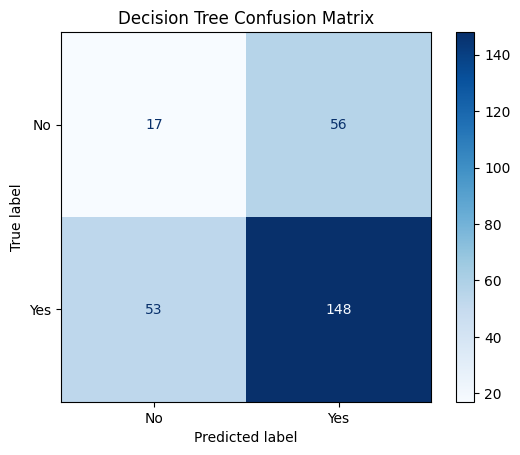

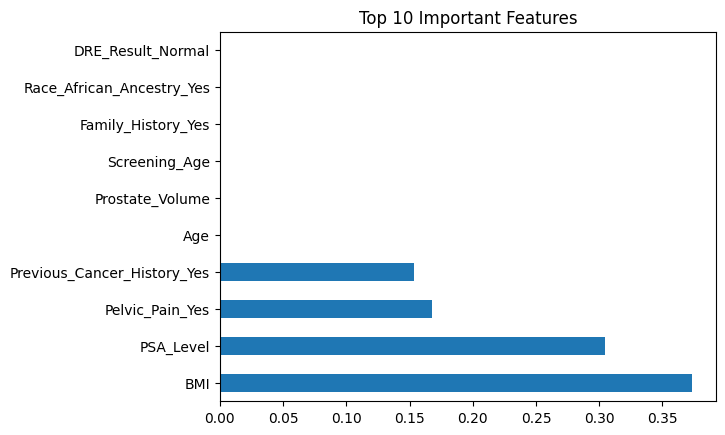

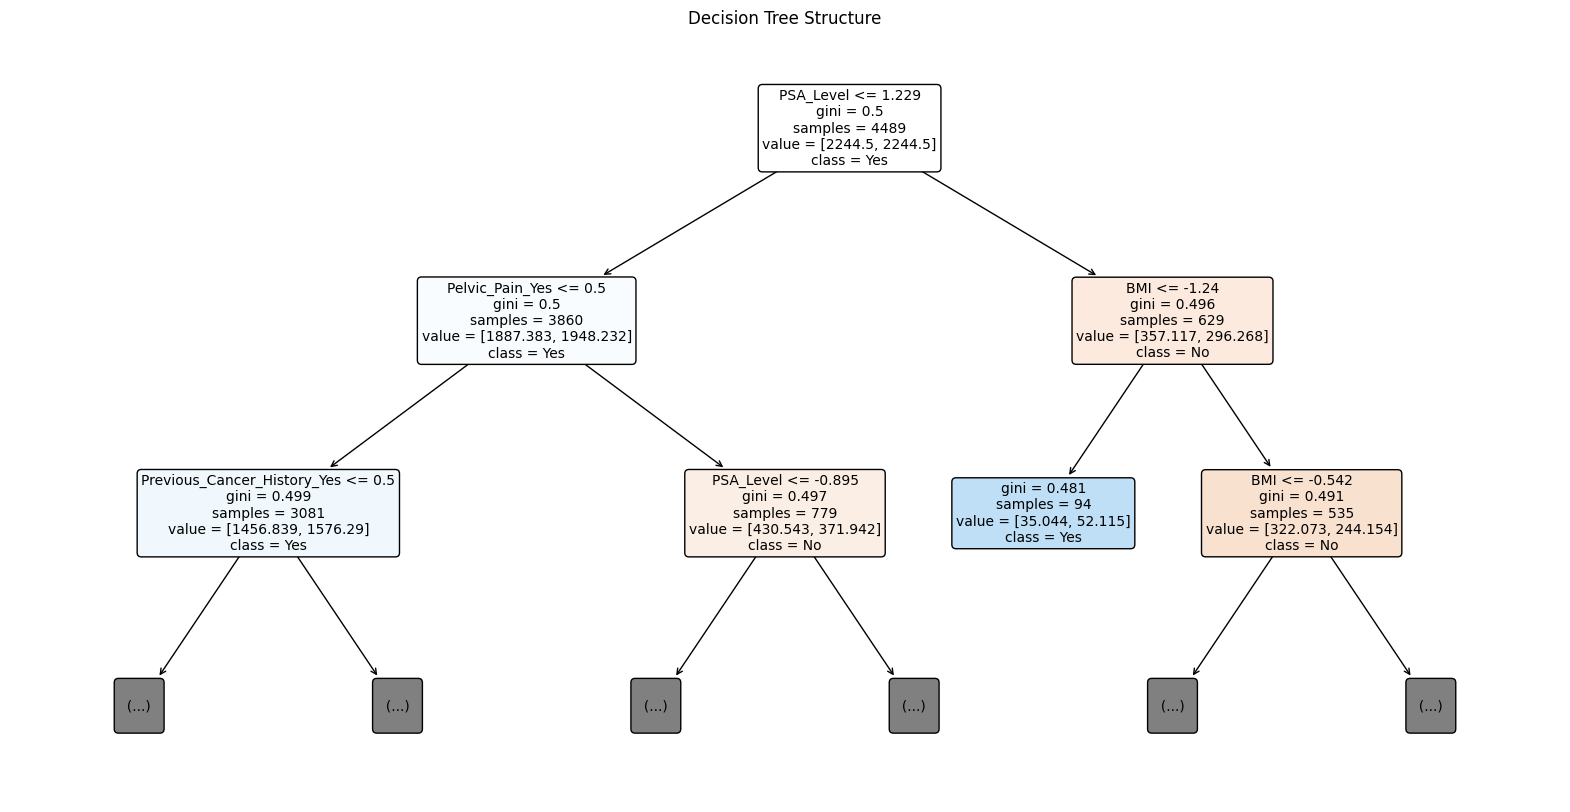


Clinical Insight:
- Root split: PSA_Level (threshold: 1.23)
- Samples: 4489
- Class 0 (No) precision: 0.24
- Class 1 (Yes) recall: 0.74


In [73]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load your preprocessed data (if saved earlier)
train_df = pd.read_csv('train_70_30_preprocessed.csv')
test_df = pd.read_csv('test_70_30_preprocessed.csv')

# Drop rows with NaN in target (due to misalignment)
train_df = train_df.dropna(subset=['Early_Detection'])
test_df = test_df.dropna(subset=['Early_Detection'])

# Ensure integer type
train_df['Early_Detection'] = train_df['Early_Detection'].astype(int)
test_df['Early_Detection'] = test_df['Early_Detection'].astype(int)

# Split
X_train = train_df.drop('Early_Detection', axis=1)
y_train = train_df['Early_Detection']
X_test = test_df.drop('Early_Detection', axis=1)
y_test = test_df['Early_Detection']


assert not y_train.isna().any()
assert set(y_train.unique()) <= {0, 1}

# 2. Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=3,  # Limit depth for interpretability
    min_samples_leaf=50,  # Prevent overfitting
    class_weight='balanced',  # Account for remaining imbalance
    random_state=42
)
dt_model.fit(X_train,y_train.values.ravel())

# 3. Evaluate
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# 5. Feature Importance
importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()

# 6. Visualize the Tree (first 3 levels)
plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=X_train.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          max_depth=2,  # Show first 2 levels for readability
          fontsize=10)
plt.title('Decision Tree Structure')
plt.show()

# 7. Output interpretation
print("\nClinical Insight:")
print(f"- Root split: {X_train.columns[dt_model.tree_.feature[0]]} (threshold: {dt_model.tree_.threshold[0]:.2f})")
print(f"- Samples: {dt_model.tree_.n_node_samples[0]}")
print(f"- Class 0 (No) precision: {cm[0,0]/(cm[0,0]+cm[1,0]):.2f}")
print(f"- Class 1 (Yes) recall: {cm[1,1]/(cm[1,1]+cm[1,0]):.2f}")

In [84]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_train_resampled).value_counts())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


Before: Early_Detection
1    3144
0    1345
Name: count, dtype: int64
After: Early_Detection
1    3144
0    3144
Name: count, dtype: int64


In [88]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [300]
}

grid = GridSearchCV(MLPClassifier(random_state=42), param_grid, cv=3, scoring='f1_weighted')
grid.fit(X_train_resampled_scaled, y_train_resampled)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_


C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Other\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the opti

Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01, 'max_iter': 300}


In [89]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes= (128, 64), 
    activation='relu',            # Good default for most problems
    solver='adam',                # Fast optimizer
    alpha=0.01,                  # L2 regularization (weight decay)
    learning_rate='adaptive',     # Slower learning if performance plateaus
    max_iter=300,                 # Allow enough epochs
    random_state=42
)

mlp_model.fit(X_train_resampled_scaled, y_train_resampled)


MLPClassifier(alpha=0.01, hidden_layer_sizes=(128, 64),
              learning_rate='adaptive', max_iter=300, random_state=42)

Classification Report:
              precision    recall  f1-score   support

      No (0)       0.29      0.22      0.25        73
     Yes (1)       0.74      0.81      0.77       201

    accuracy                           0.65       274
   macro avg       0.52      0.51      0.51       274
weighted avg       0.62      0.65      0.63       274



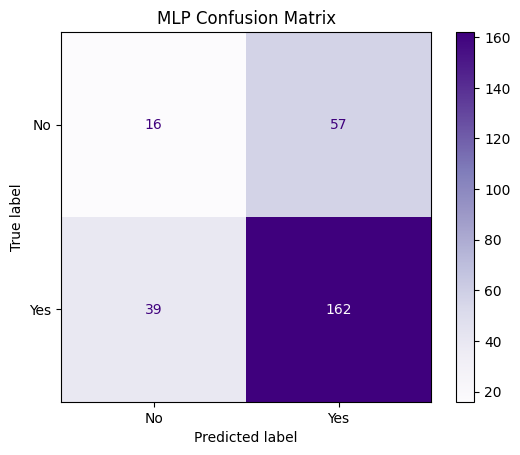

In [90]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred = mlp_model.predict(X_test_scaled)

# Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Purples')
plt.title('MLP Confusion Matrix')
plt.show()


In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 3. Train SVM
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_resampled, y_train_resampled)

# 4. Evaluate
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("✅ ROC AUC Score:", auc)


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.15      0.18        73
           1       0.73      0.82      0.77       201

    accuracy                           0.64       274
   macro avg       0.48      0.49      0.48       274
weighted avg       0.60      0.64      0.61       274

✅ ROC AUC Score: 0.492605465821577


In [81]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# 1. Enhanced Model Architecture
model = Sequential([
    Input(shape=(X_train_resampled.shape[1],)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2. Optimized Learning Rate
optimizer = Adam(learning_rate=0.0005)

# 3. Enhanced Model Compilation
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall'),
                       tf.keras.metrics.AUC(name='auc')])

# 4. Improved Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
]

# 5. Adjusted Class Weights
class_weight = {0: 2.0, 1: 0.8}  # Stronger emphasis on minority class

# 6. Train with Larger Batch Size
history = model.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.4930 - auc: 0.4881 - loss: 3.4389 - precision: 0.4975 - recall: 0.4917 - val_accuracy: 0.2664 - val_auc: 0.5349 - val_loss: 2.9277 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5255 - auc: 0.5608 - loss: 2.9341 - precision: 0.6080 - recall: 0.1906 - val_accuracy: 0.2664 - val_auc: 0.5313 - val_loss: 2.9106 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5403 - auc: 0.5791 - loss: 2.6667 - precision: 0.6180 - recall: 0.1431 - val_accuracy: 0.2664 - val_auc: 0.5374 - val_loss: 2.8928 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5431 - auc: 0.6211 - loss: 2.4329 - precision: 0.6650 - recall: 0.1822 - val_accuracy: 0.2664 - val_a